Alunos: Eduardo palhares reale pereira e João Pedro Araujo
Matricula: 202507222597 e 202301169641



QUESTÃO 1: A distância necessária para parar um automóvel consiste nas
componentes tanto de pensar como de frear, cada uma das quais é uma função
de sua velocidade. Os seguintes dados experimentais foram dados coletados
para quantificar esta relação.


Faça uma estimativa de distância de parada total para um carro movendo-se a
110km/h.
a) Apresente a solução manual por meio de Polinômio de Lagrange de 1ª
ordem para pensar (utilize os pontos de velocidade =30 e 120 km/h) e de
2ª ordem para frear (utilize os pontos de velocidade =30, 60 e 120).
b) Apresente a solução utilizando a linguagem Python.


LETRA A)

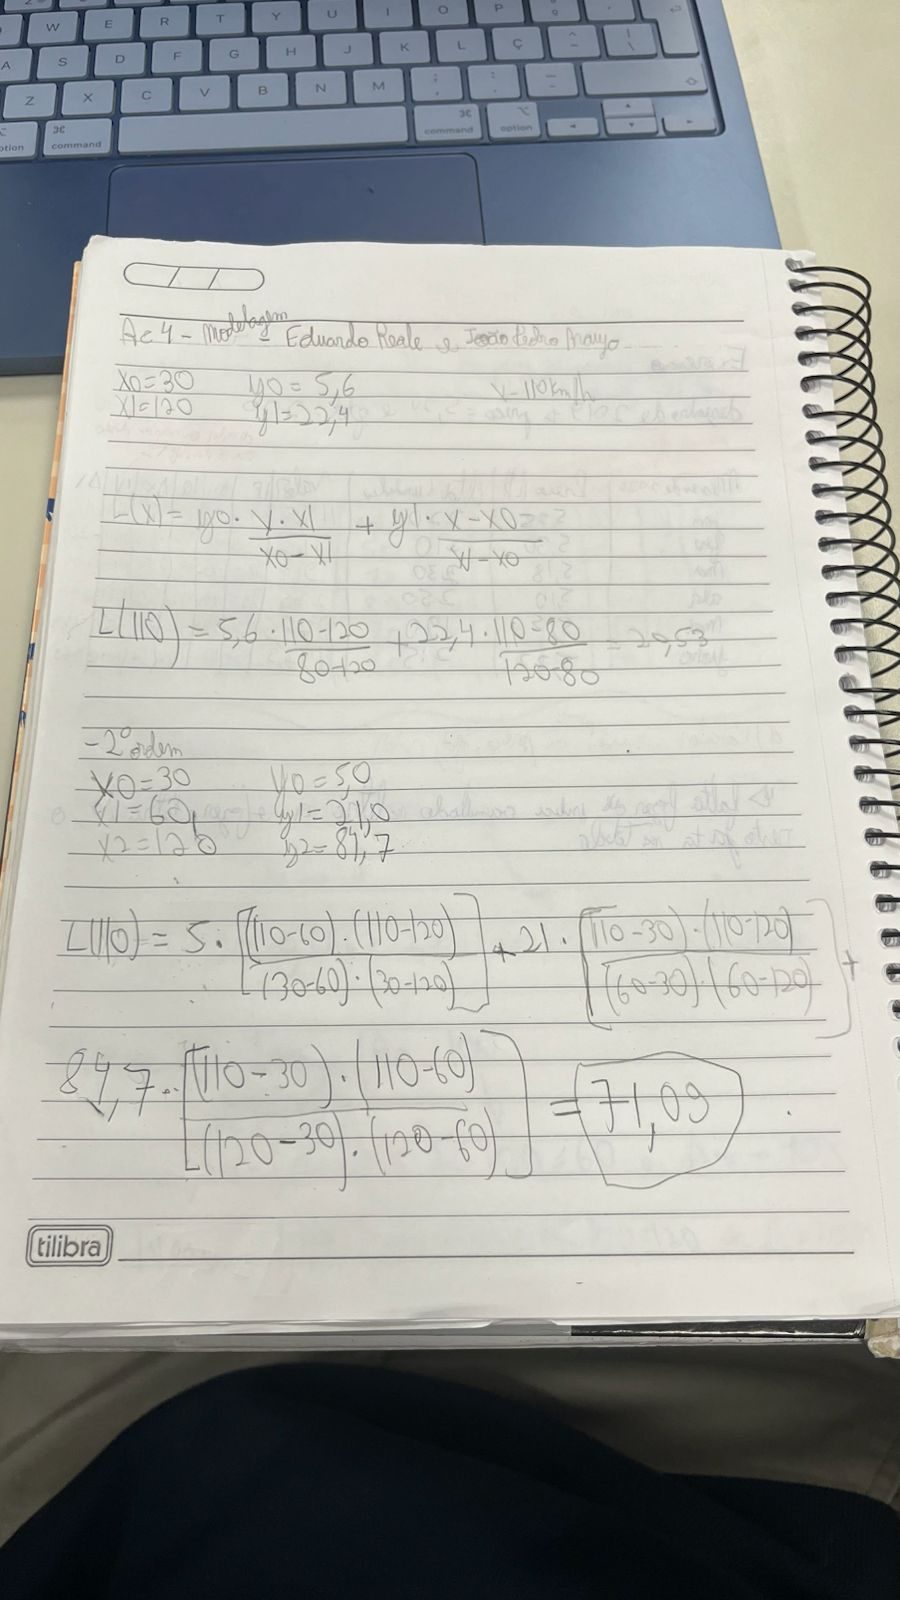


O polinomio de 1 ordem para pensar é:
  
0.1867 x

O polinomio de 2 ordem para frear é:
          2
0.00587 x + 0.005 x - 0.4333

O valor ajustado para x=1 considerando ajuste de 1 ordem é: 20.53333333333333

O valor ajustado para x=1 considerando ajuste de 1 ordem é: 71.14814814814817


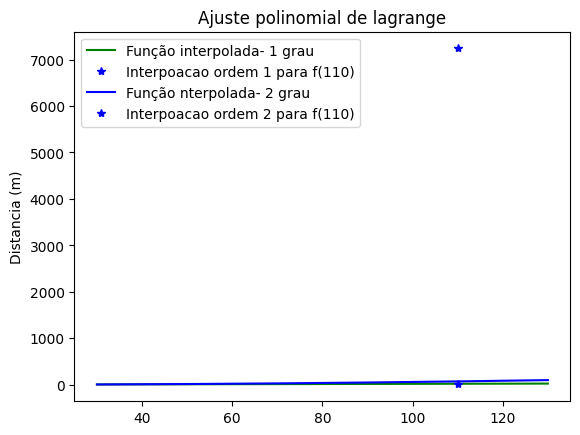

In [ ]:
#LETRA B:

from scipy.interpolate import lagrange
from numpy import array, linspace
from matplotlib.pyplot import plot, xlabel, ylabel, legend, title

x_pensar=array([30,120])
y_pensar= array([5.6,22.4])
f_pensar= lagrange(x_pensar,y_pensar)

x_frear=array([30,60,120])
y_frear=array([5,21,84.7])
f_frear=lagrange(x_frear,y_frear)

xx=linspace(30,130,200)

plot(xx,f_pensar(xx),'g', label='Função interpolada- 1 grau')
plot(110,f_pensar(110),'*b', label='Interpoacao ordem 1 para f(110)')

plot(xx,f_frear(xx), 'b', label='Função nterpolada- 2 grau')
plot(110,f_frear(1110),'*b', label='Interpoacao ordem 2 para f(110)')

title('Ajuste polinomial de lagrange')
xlabel=('Velocidade (km/h)')
ylabel('Distancia (m)')
legend()

print("\nO polinomio de 1 ordem para pensar é:\n",f_pensar)
print("\nO polinomio de 2 ordem para frear é:\n",f_frear)
print("\nO valor ajustado para x=1 considerando ajuste de 1 ordem é:",f_pensar(110))
print("\nO valor ajustado para x=1 considerando ajuste de 1 ordem é:",f_frear(110))

QUESTÃO 2: Use interpolação inversa por um polinômio interpolador cúbico e
bissecção para determinar o valor de x que corresponde a f(x) = 0,23 para os
seguintes dados tabulados:

Utilize as bibliotecas python para resolver o problema proposto. Apresente a
solução na forma gráfica e numérica.

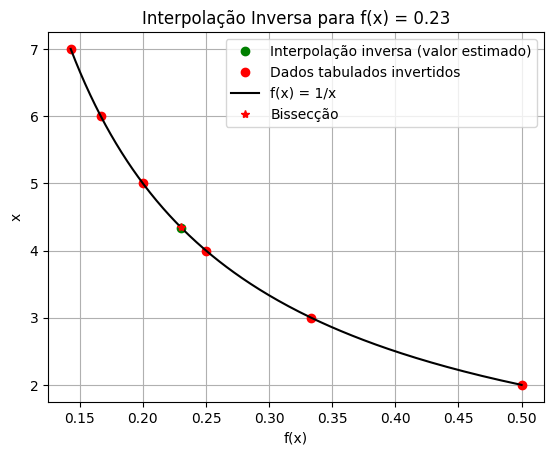

Estimativa por interpolação inversa: x = 4.341531
Estimativa por bissecção: x = 4.347826


In [ ]:
from numpy import array, linspace
from matplotlib.pyplot import plot, xlabel, ylabel, legend, title, grid, show
from scipy.interpolate import lagrange
from scipy.optimize import bisect

x = array([2, 3, 4, 5, 6, 7])
fx = array([0.5, 0.3333, 0.25, 0.2, 0.1667, 0.1429])

fx_inv = array([0.3333, 0.25, 0.2, 0.1667])
x_inv = array([3, 4, 5, 6])

polinomio_inv = lagrange(fx_inv, x_inv)
x_estimado = polinomio_inv(0.23)

def fx_func(x):
    return 1 / x

def f_raiz(x):
    return fx_func(x) - 0.23

x_bisect = bisect(f_raiz, 4, 5)

xx = linspace(2, 7, 300)
yy = fx_func(xx)

plot(0.23, x_estimado, 'og', label='Interpolação inversa (valor estimado)')
plot(fx, x, 'ro', label='Dados tabulados invertidos')
plot(yy, xx, 'k-', label='f(x) = 1/x')
plot(0.23, x_bisect, '*r', label='Bissecção')

title('Interpolação Inversa para f(x) = 0.23')
xlabel('f(x)')
ylabel('x')
legend()
grid(True)
show()

print(f"Estimativa por interpolação inversa: x = {x_estimado:.6f}")
print(f"Estimativa por bissecção: x = {x_bisect:.6f}")


QUESTÃO 3:

a- Utilize polinômios de Lagrange de ordens 1, 2 e 3 e faça a estimativa de
erro de uma ordem inferior para uma ordem superior.


b- Faça um ajuste polinomial de Newton de ordem 2. Apresente o polinômio
ajustado e o utilize para interpolar o valor desejado. Compare os valores
encontrados.


Consultando-se a tabela verificou-se que para calcular o R associado ao valor
H/h encontrado deveria ser feita uma interpolação. Qual o resultado encontrado
após a interpolação?



a) Interpolação de Lagrange:
Ordem 1: 0.58424
Ordem 2: 0.58439 e o Erro 1: 1.45860e-04
Ordem 3: 0.58440 e o Erro 2: 1.50348e-05
Ajuste Polinomial de Newton (2 grau):-0.00274x² + -0.01536x + 0.86349
Pelo ajuste: 0.58434
Erro em relação à Lagrange ordem 2: 4.35571e-05


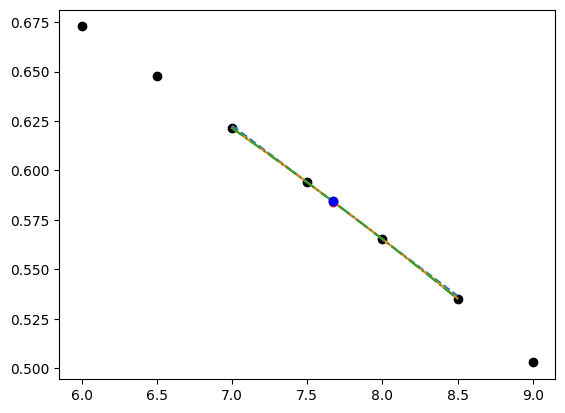

In [ ]:
from numpy import array, polyfit
from scipy.interpolate import lagrange

Hh = array([6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0])
R =  array([0.6728, 0.6476, 0.6214, 0.5940, 0.5653, 0.5350, 0.5029])
x = 7.67

#a) Interpolação de Lagrange

lag1 = lagrange([7.5, 8.0], [0.5940, 0.5653])
R1 = lag1(x)

lag2 = lagrange([7.0, 7.5, 8.0], [0.6214, 0.5940, 0.5653])
R2 = lag2(x)

lag3 = lagrange([7.0, 7.5, 8.0, 8.5], [0.6214, 0.5940, 0.5653, 0.5350])
R3 = lag3(x)

erro_1_2 = abs(R2 - R1)
erro_2_3 = abs(R3 - R2)

x_vals = linspace(7.0, 8.5, 200)
y_lag1 = lag1(x_vals)
y_lag2 = lag2(x_vals)
y_lag3 = lag3(x_vals)

plot(Hh, R, 'ko', label='Dados da Tabela')
plot(x_vals, y_lag1, '--', label='Lagrange ordem 1')
plot(x_vals, y_lag2, '-', label='Lagrange ordem 2')
plot(x_vals, y_lag3, '-.', label='Lagrange ordem 3')
plot([x], [R1], 'ro', label='ordem 1')
plot([x], [R2], 'go', label='ordem 2')
plot([x], [R3], 'bo', label='ordem 3')

print("a) Interpolação de Lagrange:")
print(f"Ordem 1: {R1:.5f}")
print(f"Ordem 2: {R2:.5f} e o Erro 1: {erro_1_2:.5e}")
print(f"Ordem 3: {R3:.5f} e o Erro 2: {erro_2_3:.5e}")

#b) Ajuste Polinomial de Newton

a, b, c = polyfit(Hh, R, 2)

R_newton = a * x**2 + b * x + c

print(f"Ajuste Polinomial de Newton (2 grau):{a:.5f}x² + {b:.5f}x + {c:.5f}")
print(f"Pelo ajuste: {R_newton:.5f}")
print(f"Erro em relação à Lagrange ordem 2: {abs(R2 - R_newton):.5e}")

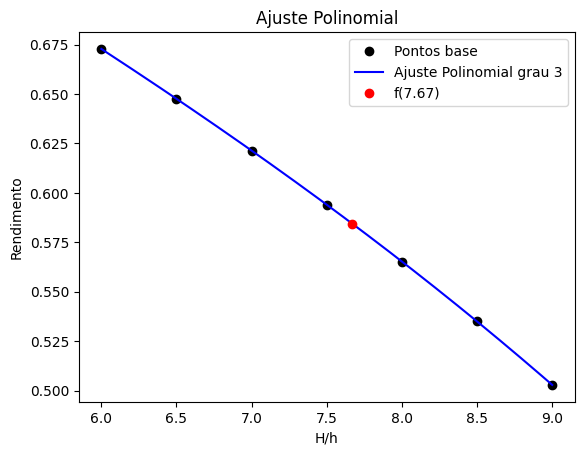

O polinômio ajustado é:
             3            2
-0.0002667 x + 0.003257 x - 0.05989 x + 0.9725

O valor ajustado para x = 7.67 é: 0.584422
O erro relativo percentual é: 5.01749%


In [ ]:
from numpy import array, polyfit, poly1d
from matplotlib.pyplot import plot, xlabel, ylabel, legend, title, show

Hh = array([6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0])
R =  array([0.6728, 0.6476, 0.6214, 0.5940, 0.5653, 0.5350, 0.5029])

coef = polyfit(Hh, R,3)
f = poly1d(coef)

x_interp = 7.67
y_real = f(x_interp)

plot(Hh, R, 'ko', label='Pontos base')
x_plot = array([min(Hh) + i * 0.01 for i in range(int((max(Hh)-min(Hh))/0.01)+1)])
plot(x_plot, f(x_plot), 'b-', label=f'Ajuste Polinomial grau {3}')
plot([x_interp], [y_real], 'ro', label=f'f({x_interp})')

title('Ajuste Polinomial')
xlabel('H/h')
ylabel('Rendimento')
legend()
show()

referencia = 0.5565
erro = abs((referencia - y_real) / referencia) * 100

print("O polinômio ajustado é:\n", f)
print(f"\nO valor ajustado para x = {x_interp} é: {round(y_real, 6)}")
print(f"O erro relativo percentual é: {round(erro, 5)}%")


Questão 4

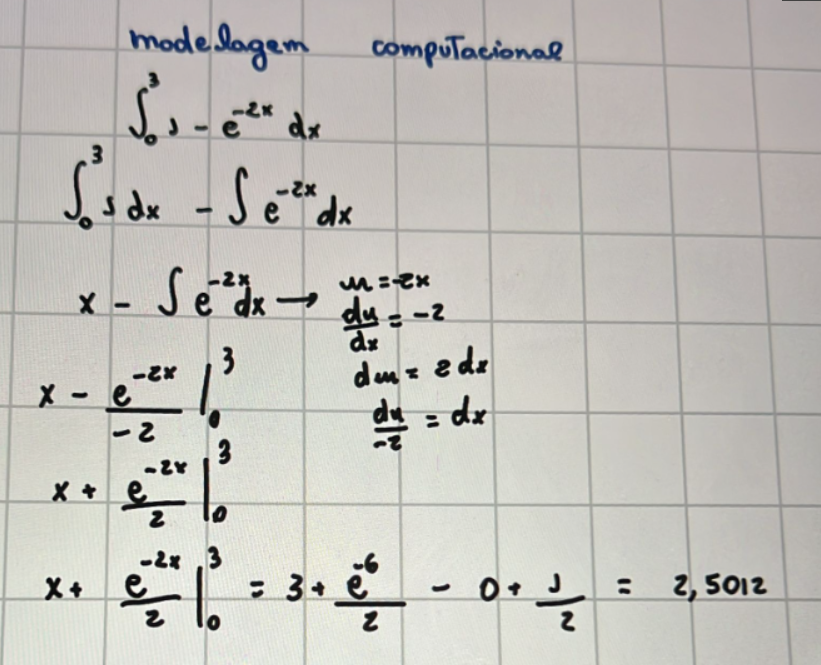

O resultado da integral por uma única aplicação da regra do trapézio é: 1.4962818717350004
O erro relativo percentual feito com uma única aplicação da regra do trapezio é:  40.1783817239027


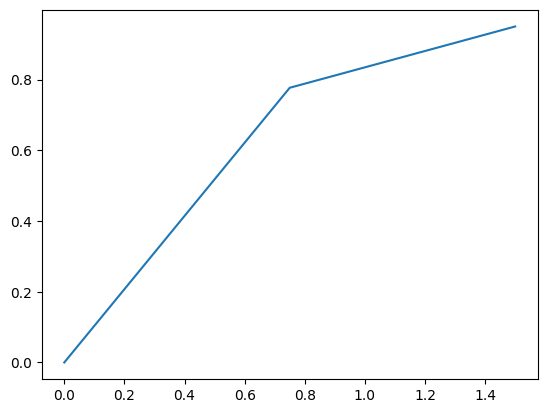

In [ ]:
#LETRA B

from numpy import array, linspace, exp
from scipy.integrate import trapezoid
from matplotlib.pyplot import plot, xlabel, ylabel, legend, title, grid, show

a=0
b=3

x=array([a,b])
def f(x):
    y=1-exp(-2*x)
    return y

xx=linspace(0,1.5,3)
plot(xx,f(xx))

y=f(x)
resultado= trapezoid(y,x)
integral_exata= 3-(1-exp(-6))/2

erro= abs(integral_exata - resultado)/abs(integral_exata)*100

print("O resultado da integral por uma única aplicação da regra do trapézio é:", resultado)
print("O erro relativo percentual feito com uma única aplicação da regra do trapezio é: ", erro)

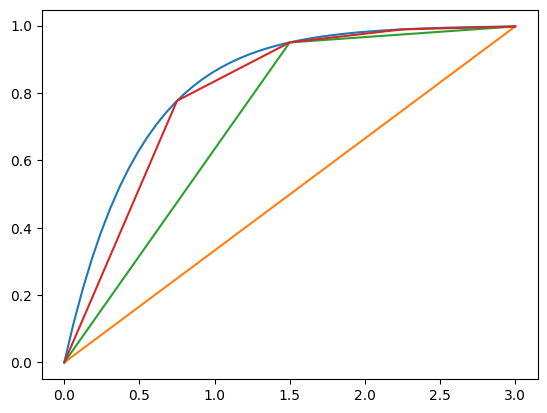

O resultado da integral aproximada para o primeiro trapezio é: 1.4962818717350004
O resultado da integral aproximada para o segundo trapezio é: 2.1734603333157043
O resultado da integral aproximada para o terceiro trapezio é: 2.4110507991428483
O erro relativo percentual para o primeiro trapezio é:  40.1783817239027
O erro relativo percentual para o primeiro trapezio é:  13.104665067493054
O erro relativo percentual para o primeiro trapezio é:  3.6057555229491967


In [ ]:
#c- por aplicações múltiplas da regra do trapézio, com n = 2 e 4;

from numpy import array, linspace, exp
from scipy.integrate import trapezoid
from matplotlib.pyplot import plot, xlabel, ylabel, legend, title, grid, show

a=0
b=3

def f(x):
    y=1-exp(-2*x)
    return y

x=linspace(0,3)
x_2=linspace(0,3,2)
x_3=linspace(0,3,3)
x_5=linspace(0,3,5)

I_1=trapezoid(f(x_2),x_2)
I_2=trapezoid(f(x_3),x_3)
I_3=trapezoid(f(x_5),x_5)

plot(x,f(x))
plot(x_2,f(x_2))
plot(x_3,f(x_3))
plot(x_5,f(x_5))
show()

integral_exata= 3-(1-exp(-6))/2
erro1= abs(integral_exata-I_1)/abs(integral_exata)*100
erro2= abs(integral_exata-I_2)/abs(integral_exata)*100
erro3= abs(integral_exata-I_3)/abs(integral_exata)*100

print("O resultado da integral aproximada para o primeiro trapezio é:", I_1)
print("O resultado da integral aproximada para o segundo trapezio é:", I_2)
print("O resultado da integral aproximada para o terceiro trapezio é:", I_3)

print("O erro relativo percentual para o primeiro trapezio é: ", erro1)
print("O erro relativo percentual para o primeiro trapezio é: ", erro2)
print("O erro relativo percentual para o primeiro trapezio é: ", erro3)


O resultado da integral por uma única aplicação da regra 1/3 de Simpson 2.399186487175939
O resultado da integral exata  por uma única aplicação da regra 1/3 de Simpson é: 2.5012393760883334
O erro relativo percentual é:  4.080092848689837


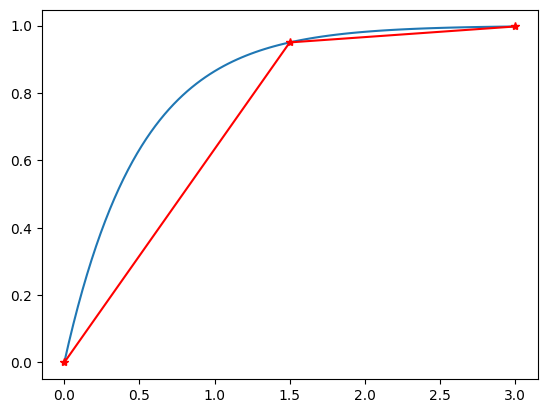

In [ ]:
#d- uma única aplicação da regra 1/3 de Simpson;



from scipy.integrate import simpson
from numpy import array, linspace
from matplotlib.pyplot import plot, xlabel, ylabel, legend, title

def f(x):
    y=1-exp(-2*x)
    return y

x = linspace(0,3,100)
plot(x, f(x), label='f(x) = 1 - e^(-2x)')

x1 = linspace(0,3,3)
I = simpson(y=f(x1), x=x1)
integral_exata= 3-(1-exp(-6))/2
erro= abs(integral_exata-I)/abs(integral_exata)*100

plot(x1, f(x1), '-*r')

print("O resultado da integral por uma única aplicação da regra 1/3 de Simpson", I)
print("O resultado da integral exata  por uma única aplicação da regra 1/3 de Simpson é:", integral_exata)
print("O erro relativo percentual é: ", erro)


O resultado da integral por uma única aplicação da regra 1/3 de Simpson 2.4902476210852296
O resultado da integral exata  por uma única aplicação da regra 1/3 de Simpson é: 2.5012393760883334
O erro relativo percentual é:  0.439452341434577


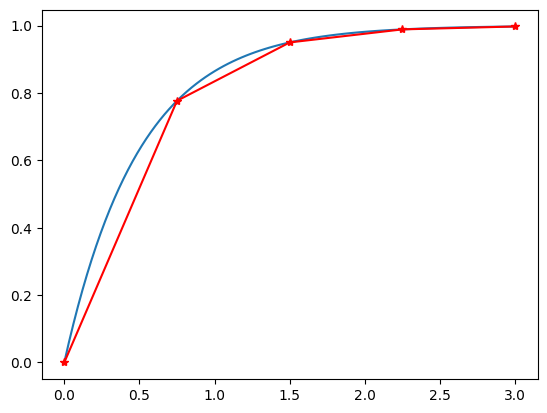

In [ ]:
#e- aplicação múltipla da regra 1/3 de Simpson, com n = 4;


from scipy.integrate import simpson
from numpy import array, linspace
from matplotlib.pyplot import plot, xlabel, ylabel, legend, title

def f(x):
    y=1-exp(-2*x)
    return y

x = linspace(0,3,100)
plot(x, f(x), label='f(x) = 1 - e^(-2x)')

x1 = linspace(0,3,5)
I = simpson(y=f(x1), x=x1)
integral_exata= 3-(1-exp(-6))/2
erro= abs(integral_exata-I)/abs(integral_exata)*100

plot(x1, f(x1), '-*r')

print("O resultado da integral por uma única aplicação da regra 1/3 de Simpson", I)
print("O resultado da integral exata  por uma única aplicação da regra 1/3 de Simpson é:", integral_exata)
print("O erro relativo percentual é: ", erro)

O resultado da integral por uma única aplicação da regra 3/8 de Simpson 1.4962818717350004
O resultado da integral exata  por uma única aplicação da regra 3/8 de Simpson é: 2.5012393760883334
O erro relativo percentual é:  40.1783817239027


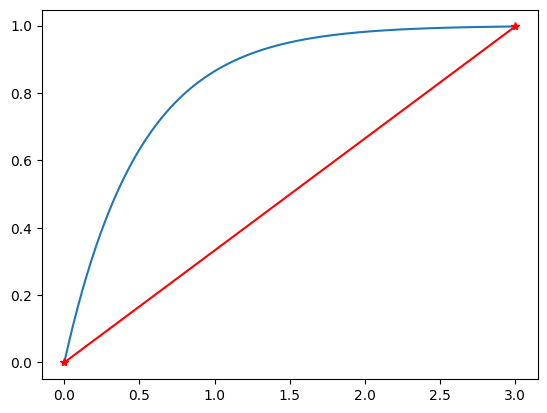

In [ ]:
#f- uma única aplicação da regra 3/8 de Simpson (implemente a fórmula de 3/8 de Simpson em Python);

from scipy.integrate import simpson
from numpy import array, linspace
from matplotlib.pyplot import plot, xlabel, ylabel, legend, title

def f(x):
    y=1-exp(-2*x)
    return y

x = linspace(0,3,100)
plot(x, f(x), label='f(x) = 1 - e^(-2x)')

x1 = linspace(0,3,2)
I = simpson(y=f(x1), x=x1)
integral_exata= 3-(1-exp(-6))/2
erro= abs(integral_exata-I)/abs(integral_exata)*100

plot(x1, f(x1), '-*r')

print("O resultado da integral por uma única aplicação da regra 3/8 de Simpson", I)
print("O resultado da integral exata  por uma única aplicação da regra 3/8 de Simpson é:", integral_exata)
print("O erro relativo percentual é: ", erro)

O resultado da integral por uma única aplicação da regra 3/8 de Simpson 2.4902476210852296
O resultado da integral exata  por uma única aplicação da regra 3/8 de Simpson é: 2.5012393760883334
O erro relativo percentual é:  0.439452341434577


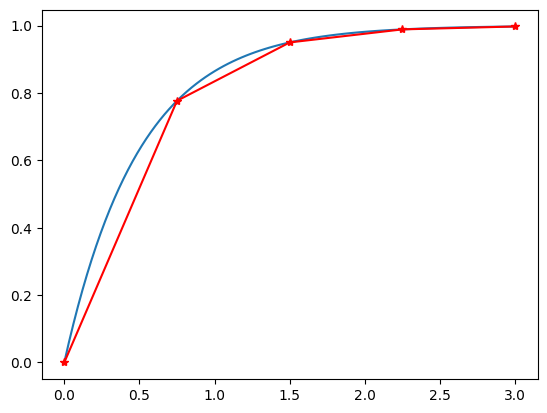

In [ ]:
#g- aplicação múltipla da regra de Simpson, com n = 5.


from scipy.integrate import simpson
from numpy import array, linspace
from matplotlib.pyplot import plot, xlabel, ylabel, legend, title

def f(x):
    y=1-exp(-2*x)
    return y

x = linspace(0,3,100)
plot(x, f(x), label='f(x) = 1 - e^(-2x)')

x1 = linspace(0,3,5)
I = simpson(y=f(x1), x=x1)
integral_exata= 3-(1-exp(-6))/2
erro= abs(integral_exata-I)/abs(integral_exata)*100

plot(x1, f(x1), '-*r')

print("O resultado da integral por uma única aplicação da regra 3/8 de Simpson", I)
print("O resultado da integral exata  por uma única aplicação da regra 3/8 de Simpson é:", integral_exata)
print("O erro relativo percentual é: ", erro)

Questão 5)

In [ ]:
from scipy.integrate import simpson
from numpy import array, linspace
from matplotlib.pyplot import plot, xlabel, ylabel, legend, title

y=array([0,1,3,5,7,8,9,10])
h=array([0,1,1.5,3,3.5,3.2,2,0])
u=array([0,0.1,0.12,0.2,0.25,0.3,0.15,0])

#LETRA A- Profundidade média:
Ac= simpson(h,y)
A_medio= Ac/ (y[-1] - y[0])
print("A profundidade média é:", A_medio)

#LETRA B- A área da seção transversal:
print("A área da seção transversal é:", Ac)

#LETRA C- Velocidade média:
HU= h*u
Q= simpson(HU,y)
U_medio= Q/Ac
print("A velocidade média é:",U_medio )

#LETRA D- Taxa de escoamento:
print("A taxa de escoamento é:", Q)

A profundidade média é: 2.1874999999999996
A área da seção transversal é: 21.874999999999996
A velocidade média é: 0.2036571428571429
A taxa de escoamento é: 4.455
